# Brain Tumor Detection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### read images

In [ ]:
import os
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

DATASET_PATH = "./"  # change if needed

IMG_SIZE = (128, 128)

def load_data(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder, filename)
            img = load_img(path, target_size=IMG_SIZE)
            img = img_to_array(img) / 255.0
            images.append(img)
    return np.array(images)

yes_images = load_data(os.path.join(DATASET_PATH, "yes"))
no_images = load_data(os.path.join(DATASET_PATH, "no"))

print("Yes:", yes_images.shape)
print("No:", no_images.shape)

Yes: (155, 128, 128, 3)
No: (98, 128, 128, 3)


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

X = np.concatenate([yes_images, no_images], axis=0)

y = np.concatenate([
    np.ones(len(yes_images)),
    np.zeros(len(no_images))
]).astype(int)

X_train, X_test, y_train_lbl, y_test_lbl = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

y_train = tf.keras.utils.to_categorical(y_train_lbl, 2)
y_test = tf.keras.utils.to_categorical(y_test_lbl, 2)

### Build CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Flatten

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Jitesh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,522 (32.36 MB)

 Trainable params: 8,483,074 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

### Training and Saving of accuracy & Loss at train time and validation time

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

early_stop = EarlyStopping(patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=4, factor=0.5)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.6584 - loss: 4.7915 - val_accuracy: 0.7843 - val_loss: 0.5243 - learning_rate: 5.0000e-04
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.6287 - loss: 4.4472 - val_accuracy: 0.6667 - val_loss: 0.5690 - learning_rate: 5.0000e-04
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.6584 - loss: 3.2848 - val_accuracy: 0.6863 - val_loss: 0.9490 - learning_rate: 5.0000e-04
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.7772 - loss: 1.3413 - val_accuracy: 0.7255 - val_loss: 0.9921 - learning_rate: 5.0000e-04
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.7376 - loss: 1.1320 - val_accuracy: 0.6863 - val_loss: 1.1533 - learning_rate: 5.0000e-04
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step - accuracy: 0.7178 - loss: 0.6735 - val_accuracy: 0.6471 - val_loss: 1.3470 - learning_rate: 2.5000e-04
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.7475 - loss:

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7843 - loss: 0.5243
Test Accuracy: 78.43%


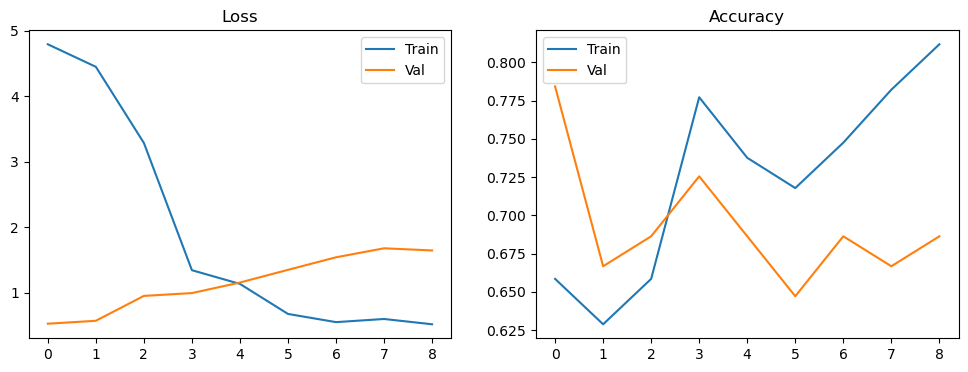

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.show()